# Run this to enable loading from relative packes

In [1]:
%load_ext autoreload
%autoreload 2
if "PKG" not in globals():
  import importlib, sys, pathlib # https://stackoverflow.com/a/50395128/11996983
  PKG = %pwd
  PKG = pathlib.Path(PKG)
  root_parent_level = 2
  root = PKG
  full_pkg = f"{root.name}"
  for _ in range(root_parent_level):
    root = root.parent
    full_pkg = f"{root.name}.{full_pkg}"
    MODULE_PATH = f"{root}{pathlib.os.path.sep}__init__.py"
    MODULE_NAME = f"{root.name}"
    spec = importlib.util.spec_from_file_location(MODULE_NAME, MODULE_PATH)
    module = importlib.util.module_from_spec(spec)
    sys.modules[spec.name] = module
    spec.loader.exec_module(module)
  __package__ = full_pkg


# Save plots with no embeded fonts

In [2]:
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']


# Figures Save Path

In [3]:
import platform
import os
if "Ubuntu" in platform.version():
  os.environ["OnedriveConsumer"] = rf"{os.path.expanduser('~')}/OnedrivePersonal/"
  os.environ["OnedriveCommercial"] = rf"{os.path.expanduser('~')}/OnedriveFloating/"

In [4]:
from ...common.util import onedrivepath
onedrivepath.setOnedriveEnvIfLinux(onedrivepath.OnedriveCommercialEnvVar)
onedrivepath.setOnedriveEnvIfLinux(onedrivepath.OnedriveConsumerEnvVar)

Onedrive OnedriveCommercial path: C:\Users\float\OneDrive - Floating Reality
Onedrive OnedriveConsumer path: C:\Users\float\OneDrive


In [5]:
fig_save_prefix = f"{os.environ['OnedriveCommercial']}/analysis/ver2/evd_model/"

# Load model fitting

In [6]:
# https://stackoverflow.com/a/53327348/11996983
import pickle
from .model import drift, noise, bias, visualize

def _renameFn(name):
     # print("Renaming: ", name)
     if name == "_BiasAffinity":
          return "BiasAffinity"
     elif name == "_driftDriftQRewardRate":
          return "_decayQRewardRate"
     elif name == "_driftClassicAddQ":
          return "_contanstQRewardRate"
     elif name == "_driftRewardRateNoiseGain":
          return "_noiseGainRewardRate"
     elif name == "NoiseGain":
          return "NoiseGain-RewardRate"
     return name

class AnyObject:
     pass

class RenameUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        renamed_module = module
        name = _renameFn(name)
        fn = getattr(bias, name, None)
        if fn is not None:
            return fn
        fn = getattr(drift, name, None)
        if fn is not None:
            return fn
        fn = getattr(noise, name, None)
        if fn is not None:
            return fn
        if name == "_PsychometricPlot":
            return visualize.PsychometricPlot
        name_split = renamed_module.split(".")
        if name_split[0] == "code":
            renamed_module = "model_code" + "." + ".".join(name_split[1:])
        # print("Finding:", renamed_module, ":", name)
        return super(RenameUnpickler, self).find_class(renamed_module, name)
        # return super(RenameUnpickler, self).find_class(renamed_module, name)
        # try:
        #     __import__(module, level=0)
        #     return getattr(sys.modules[module], name)
        # except AttributeError:
        #     print(f"Attribute {name} not found in module {module}, returning AnyObject")
        #     return AnyObject
        # except ModuleNotFoundError:
        #     print(f"Module {module} not found, returning AnyObject for {name}")
        #     return AnyObject


def renamedLoad(file_obj):
    return RenameUnpickler(file_obj).load()


In [7]:
from pathlib import Path
import pandas as pd

def loadAll():
    evolve_res_dict_dict = {}
    all_sunjects = set() #df_behavior.Name.unique()
    for fp in Path("evolvs_res_dump").iterdir():
        # print("Processing:", fp)
        if not fp.is_file() or not (#fp.name.startswith("evolvs_") and 
                                    fp.name.endswith(".pkl")):
            continue
        print("Loading:", fp)
        with fp.open('rb') as f:
            _evolve_loaded = renamedLoad(f)
            evolve_res_dict_dict[fp.name] = _evolve_loaded
            missing_subjects = {key for key in all_sunjects  if key not in _evolve_loaded}
            if missing_subjects:
                print("Missing subjects:", missing_subjects, "from file:", fp)
        # _evolve_loaded = pd.read_pickle(fp)
        evolve_res_dict_dict[fp.name] = _evolve_loaded
            
    return evolve_res_dict_dict

evolve_res_dict_dict = loadAll()
evolve_res_dict_dict.keys()

Loading: evolvs_res_dump\Classic_biasNone__Normal(0, 1)_3s_dt0.005.pkl
Loading: evolvs_res_dump\Classic_biasQ-Val (Offset)_Normal(0, 1)_3s_dt0.005.pkl
Loading: evolvs_res_dump\Classic_biasQ-Val_Normal(0, 1)_3s_dt0.005.pkl
Loading: evolvs_res_dump\Classic_biasQ-Val_Normal(0, 1)_loss_no_dir_3s_dt0.005.pkl
Loading: evolvs_res_dump\Decay Q (Offset)_biasNone__Normal(0, 1)_3s_dt0.005.pkl
Loading: evolvs_res_dump\Decay Q_biasNone__Normal(0, 1)_3s_dt0.005.pkl
Loading: evolvs_res_dump\NoiseGain-RewardRate Decay Q (Offset)_biasNone__Normal(0, 1)_3s_dt0.005.pkl
Loading: evolvs_res_dump\NoiseGain-RewardRate Decay Q_biasNone__Normal(0, 1)_3s_dt0.005.pkl
Loading: evolvs_res_dump\NoiseGain-RewardRate_biasNone__Normal(0, 1)_3s_dt0.005.pkl
Loading: evolvs_res_dump\NoiseGain-RewardRate_biasQ-Val (Offset)_Normal(0, 1)_3s_dt0.005.pkl
Loading: evolvs_res_dump\NoiseGain-RewardRate_biasQ-Val_Normal(0, 1)_3s_dt0.005.pkl
Loading: evolvs_res_dump\NoiseGain-RewardRate_biasQ-Val_Normal(0, 1)_loss_no_dir_3s_dt0.00

dict_keys(['Classic_biasNone__Normal(0, 1)_3s_dt0.005.pkl', 'Classic_biasQ-Val (Offset)_Normal(0, 1)_3s_dt0.005.pkl', 'Classic_biasQ-Val_Normal(0, 1)_3s_dt0.005.pkl', 'Classic_biasQ-Val_Normal(0, 1)_loss_no_dir_3s_dt0.005.pkl', 'Decay Q (Offset)_biasNone__Normal(0, 1)_3s_dt0.005.pkl', 'Decay Q_biasNone__Normal(0, 1)_3s_dt0.005.pkl', 'NoiseGain-RewardRate Decay Q (Offset)_biasNone__Normal(0, 1)_3s_dt0.005.pkl', 'NoiseGain-RewardRate Decay Q_biasNone__Normal(0, 1)_3s_dt0.005.pkl', 'NoiseGain-RewardRate_biasNone__Normal(0, 1)_3s_dt0.005.pkl', 'NoiseGain-RewardRate_biasQ-Val (Offset)_Normal(0, 1)_3s_dt0.005.pkl', 'NoiseGain-RewardRate_biasQ-Val_Normal(0, 1)_3s_dt0.005.pkl', 'NoiseGain-RewardRate_biasQ-Val_Normal(0, 1)_loss_no_dir_3s_dt0.005.pkl'])

In [8]:
KEY = "NoiseGain-RewardRate_biasQ-Val_Normal(0, 1)_3s_dt0.005.pkl"
evolve_res_dict_dict[KEY]

{'Avgat1': {'OptimRes':              message: Optimization terminated successfully.
               success: True
                   fun: 286.4872248752247
                     x: [ 4.659e-01  3.539e+00  2.947e+01  7.713e-01
                          5.631e-02  4.603e-01  1.000e+00]
                   nit: 53
                  nfev: 4860
            population: [[ 4.659e-01  3.539e+00 ...  4.603e-01  1.000e+00]
                         [ 4.680e-01  3.474e+00 ...  5.722e-01  1.000e+00]
                         ...
                         [ 4.698e-01  3.553e+00 ...  7.554e-02  1.000e+00]
                         [ 4.655e-01  3.524e+00 ...  6.343e-01  1.000e+00]]
   population_energies: [ 2.865e+02  2.943e+02 ...  2.946e+02  2.939e+02],
  'fixed_params_names': array(['df', 'biasFn', 'biasFn_df_cols', 'biasFn_kwargs', 'driftFn',
         'driftFn_df_cols', 'driftFn_kwargs', 'noiseFn', 'noiseFn_df_cols',
         'noiseFn_kwargs', 'include_Q', 'include_RewardRate', 'dt', 't_dur',
         '

# Fit data and resample if required

In [10]:
import numpy as np
from tqdm.auto import tqdm
from .model.logic import makeOneRun


def runDataFit(df, *, include_Q, include_RewardRate, 
               biasFn, biasFn_df_cols, biasFn_kwargs,
               driftFn, driftFn_df_cols, driftFn_kwargs,
               noiseFn, noiseFn_df_cols, noiseFn_kwargs,
               ALPHA, BETA, NON_DECISION_TIME,
               DRIFT_COEF, NOISE_SIGMA, BOUND, dt, t_dur):
    ret = makeOneRun(df, include_Q=include_Q, include_RewardRate=include_RewardRate,
                        biasFn=biasFn,   biasFn_df_cols=biasFn_df_cols,   biasFn_kwargs=biasFn_kwargs,
                        driftFn=driftFn, driftFn_df_cols=driftFn_df_cols, driftFn_kwargs=driftFn_kwargs,
                        noiseFn=noiseFn, noiseFn_df_cols=noiseFn_df_cols, noiseFn_kwargs=noiseFn_kwargs,
                        ALPHA=ALPHA, BETA=BETA, NON_DECISION_TIME=NON_DECISION_TIME,
                        DRIFT_COEF=DRIFT_COEF, NOISE_SIGMA=NOISE_SIGMA,
                        BOUND=BOUND, dt=dt, t_dur=t_dur, return_df=True)
    return ret

def _resampleSess(concat_subj_df, resample_count, random_dv=False):
    print_once = True # Change to false to debug and print only once
    # _RANDOM_DV_STEP = 0.01
    # RANDOM_DV_POOL = np.arange(-1, 1 + _RANDOM_DV_STEP, _RANDOM_DV_STEP) 
    rndm_gen = np.random.Generator(np.random.PCG64(0))  # For reproducibility
    def resampleFn(sess_df):
        nonlocal print_once
        sess_df = sess_df.copy()
        trial_number = sess_df["TrialNumber"].values.copy()
        valid_idx = sess_df["valid"]
        sess_df.loc[valid_idx, :] = sess_df.loc[valid_idx, :].sample(frac=1, replace=True,
                                                                        random_state=rndm_gen).values
        sess_df["TrialNumber"] = trial_number
        if not print_once:
            print_once = True
            display(sess_df[sess_df["valid"]].TrialNumber)
        assert sess_df[sess_df["valid"]].TrialNumber.is_monotonic_increasing, (
            display(sess_df[sess_df["valid"]].TrialNumber) or
            "TrialNumber is not monotonic increasing after resampling")
        return sess_df
    
    uniq_sess = concat_subj_df[["Name", "Date", "SessionNum"]
                               ].drop_duplicates().reset_index(drop=True)
    resampled_sess_li = []
    for count in tqdm(range(len(uniq_sess)*resample_count),
                      desc="Resampling sessions"):
        # Pick a random session and resample it
        sess_idx = rndm_gen.choice(uniq_sess.index)
        sess_row = uniq_sess.iloc[sess_idx]
        sess_df = concat_subj_df[(concat_subj_df["Name"] == sess_row["Name"]) &
                                 (concat_subj_df["Date"] == sess_row["Date"]) &
                                 (concat_subj_df["SessionNum"] == sess_row["SessionNum"])]
        sess_df = resampleFn(sess_df)
        sess_df["SessionNum"] = f"Random_{count}"
        sess_df["SessId"] = f"{sess_row['Name']}_{sess_row['Date']}_Random_{count}"
        resampled_sess_li.append(sess_df)
    concat_rndm_df = pd.concat(resampled_sess_li)
    if random_dv:
        concat_rndm_df["DV"] = rndm_gen.uniform(-1, 1, size=len(concat_rndm_df))
        concat_rndm_df["LeftRewarded"] = concat_rndm_df["DV"] > 0
        zero_dv_mask = concat_rndm_df["DV"] == 0
        if zero_dv_mask.any():
            concat_rndm_df.loc[concat_rndm_df, "LeftRewarded"] = \
                        rndm_gen.choice([True, False],  size=zero_dv_mask.sum())
    concat_subj_df = pd.concat([concat_subj_df, concat_rndm_df],
                                ignore_index=True).reset_index(drop=True)
    # display(concat_subj_df)
    return concat_subj_df
    

def combineDFs(evolve_res, key, resample_count=100, random_dv=False):
    # key example: "NoiseGain-RewardRate_biasQ-Val_Normal(0, 1)_3s_dt0.005.pkl"
    key_split = key.replace(".pkl", "").split("_")
    DT = float(key_split[-1].strip("dt"))
    T_DUR = float(key_split[-2].strip("s"))
    example_subj = next(iter(evolve_res.values()))
    print("Example subject:", example_subj.keys())
    FIXED_PARAMS_NAMES = list(example_subj["fixed_params_names"])
    print("PARAMS_NAMES:", FIXED_PARAMS_NAMES)
    FIXED_PARAMS_VALS = example_subj["fixed_params_vals"]
    Include_Q = bool(FIXED_PARAMS_VALS[FIXED_PARAMS_NAMES.index("include_Q")])
    Include_RewardRate = bool(FIXED_PARAMS_VALS[FIXED_PARAMS_NAMES.index("include_RewardRate")])
    BiasFn = FIXED_PARAMS_VALS[FIXED_PARAMS_NAMES.index("biasFn")]
    DriftFn = FIXED_PARAMS_VALS[FIXED_PARAMS_NAMES.index("driftFn")]
    NoiseFn = FIXED_PARAMS_VALS[FIXED_PARAMS_NAMES.index("noiseFn")]

    BIAS_KWARGS_KEYS = FIXED_PARAMS_VALS[FIXED_PARAMS_NAMES.index("biasFn_kwargs")]
    DIFT_KWARGS_KEYS = FIXED_PARAMS_VALS[FIXED_PARAMS_NAMES.index("driftFn_kwargs")]
    NOISE_KWARGS_KEYS = FIXED_PARAMS_VALS[FIXED_PARAMS_NAMES.index("noiseFn_kwargs")]
    print("Bias Fn:", BiasFn, "BiasFn_kwargs:", BIAS_KWARGS_KEYS)
    print("Drift Fn:", DriftFn, "DriftFn_kwargs:", DIFT_KWARGS_KEYS)
    print("Noise Fn:", NoiseFn, "NoiseFn_kwargs:", NOISE_KWARGS_KEYS)
    
    DRIFT_FN_COLS = FIXED_PARAMS_VALS[FIXED_PARAMS_NAMES.index("driftFn_df_cols")]
    NOISE_FN_COLS = FIXED_PARAMS_VALS[FIXED_PARAMS_NAMES.index("noiseFn_df_cols")]
    BIAS_FN_COLS = FIXED_PARAMS_VALS[FIXED_PARAMS_NAMES.index("biasFn_df_cols")]

    DF_IDX = FIXED_PARAMS_NAMES.index("df")
    concat_subj_df = []
    for subj, subject_res in evolve_res.items():
        _subj_df = subject_res["fixed_params_vals"][DF_IDX]
        _subj_df = _subj_df.copy()
        _subj_df["Name"] = subj # Fix the subject name
        concat_subj_df.append(_subj_df)
    concat_subj_df = pd.concat(concat_subj_df, ignore_index=True).reset_index(drop=True)
    if resample_count > 0:
         concat_subj_df = _resampleSess(concat_subj_df, resample_count, random_dv=random_dv)
 
    df_li = []
    for subject, subject_res in evolve_res.items():
        print("Processing subject:", subject)
        subj_fixed_parmas_vals = subject_res["fixed_params_vals"]
        subj_params_names = list(subject_res["params_names"]) # Also convert from numpy array to list
        subject_fit_params_vals = subject_res["OptimRes"]["x"]
        
        # print("Params names:", subj_params_names)
        # subj_df = subj_fixed_parmas_vals[DF_IDX]
        subj_df = concat_subj_df[concat_subj_df["Name"] == subject].copy()


        DRIFT_COEF = float(subject_fit_params_vals[subj_params_names.index("DRIFT_COEF")])
        NOISE_SIGMA = float(subject_fit_params_vals[subj_params_names.index("NOISE_SIGMA")])
        BOUND = float(subject_fit_params_vals[subj_params_names.index("BOUND")])
        ALPHA = float(subject_fit_params_vals[subj_params_names.index("ALPHA")])
        BETA = float(subject_fit_params_vals[subj_params_names.index("BETA")])
        NON_DECISION_TIME = float(subject_fit_params_vals[subj_params_names.index("NON_DECISION_TIME")])

        driftFn_kwargs = {k: float(subject_fit_params_vals[subj_params_names.index(k)]) for k in DIFT_KWARGS_KEYS}
        noiseFn_kwargs = {k: float(subject_fit_params_vals[subj_params_names.index(k)]) for k in NOISE_KWARGS_KEYS}
        biasFn_kwargs = {k: float(subject_fit_params_vals[subj_params_names.index(k)]) for k in BIAS_KWARGS_KEYS}
        
        ret = runDataFit(subj_df, include_Q=Include_Q, include_RewardRate=Include_RewardRate,
                         biasFn=BiasFn, biasFn_df_cols=BIAS_FN_COLS, biasFn_kwargs=biasFn_kwargs,
                         driftFn=DriftFn, driftFn_df_cols=DRIFT_FN_COLS, driftFn_kwargs=driftFn_kwargs,
                         noiseFn=NoiseFn, noiseFn_df_cols=NOISE_FN_COLS, noiseFn_kwargs=noiseFn_kwargs,
                         ALPHA=ALPHA, BETA=BETA, NON_DECISION_TIME=NON_DECISION_TIME,
                         DRIFT_COEF=DRIFT_COEF, NOISE_SIGMA=NOISE_SIGMA,
                         BOUND=BOUND, dt=DT, t_dur=T_DUR)
        _, subj_df = ret
        df_li.append(subj_df)
    res_df = pd.concat(df_li, ignore_index=True).reset_index(drop=True)
    res_df = res_df[res_df["valid"]]
    return res_df

df_model_behavior = combineDFs(evolve_res_dict_dict[KEY], KEY,
                               resample_count=1_000, random_dv=True)
df_model_behavior#.head()

Example subject: dict_keys(['OptimRes', 'fixed_params_names', 'fixed_params_vals', 'params_names', 'params_init', 'dt', 't_dur', 'subject_df', 'include_Q', 'include_RewardRate'])
PARAMS_NAMES: ['df', 'biasFn', 'biasFn_df_cols', 'biasFn_kwargs', 'driftFn', 'driftFn_df_cols', 'driftFn_kwargs', 'noiseFn', 'noiseFn_df_cols', 'noiseFn_kwargs', 'include_Q', 'include_RewardRate', 'dt', 't_dur', 'return_df']
Bias Fn: functools.partial(<function _biasQVal at 0x00000296EC82A8E0>, Q_VAL_OFFSET=0.0) BiasFn_kwargs: ['BIAS_COEF']
Drift Fn: <function _noiseGainRewardRate at 0x00000296EC82A2A0> DriftFn_kwargs: []
Noise Fn: <function _noiseNormal at 0x00000296EC82A480> NoiseFn_kwargs: []


Resampling sessions:   0%|          | 0/40000 [00:00<?, ?it/s]

Processing subject: Avgat1
Processing subject: Avgat2
Processing subject: Avgat3
Processing subject: BVGAT1
Processing subject: GP4-24
Processing subject: GP4-80
Processing subject: GP4-81
Processing subject: GP4-85
Processing subject: RDK_WT1
Processing subject: RDK_WT6
Processing subject: Rbp4_M2_1
Processing subject: WF10
Processing subject: WF11
Processing subject: vgat-40
Processing subject: vgat-94
Processing subject: vgat-95
Processing subject: vgat-96
Processing subject: vgat2.5
Processing subject: vgatchr2-sk
Processing subject: widefield_1


c:\Users\float\miniconda3\Lib\site-packages\IPython\lib\pretty.py:778: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  output = repr(obj)
c:\Users\float\miniconda3\Lib\site-packages\IPython\core\formatters.py:344: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  return method()


,DVabs,DV,DVstr,valid,calcStimulusTime,ChoiceCorrect,ChoiceLeft,Name,Date,SessionNum,...,SessId,SimRT,SimStartingPoint,SimChoiceCorrect,SimChoiceLeft,Q_L,Q_R,Q_val,RewardRate,LeftRewarded
30,1.0,1.000000,Easy,True,1.2517,1.0,1.0,Avgat1,2021-06-15,3,...,widefield_1_2021-06-15 00:00:00_3,0.870,-0.009011,1.0,1.0,0.478514,0.999822,-0.160014,0.228732,NaN
31,1.0,1.000000,Easy,True,1.2897,1.0,1.0,Avgat1,2021-06-15,3,...,widefield_1_2021-06-15 00:00:00_3,0.585,-0.004039,1.0,1.0,0.718561,0.999822,-0.071730,0.823586,NaN
32,1.0,-1.000000,Easy,True,0.9000,1.0,0.0,Avgat1,2021-06-15,3,...,widefield_1_2021-06-15 00:00:00_3,0.650,-0.002012,1.0,0.0,0.848111,0.999822,-0.035735,0.959649,NaN
33,1.0,1.000000,Easy,True,1.1409,1.0,1.0,Avgat1,2021-06-15,3,...,widefield_1_2021-06-15 00:00:00_3,0.520,-0.002013,1.0,1.0,0.848111,0.999904,-0.035753,0.990770,NaN
34,1.0,-1.000000,Easy,True,0.7141,0.0,1.0,Avgat1,2021-06-15,3,...,widefield_1_2021-06-15 00:00:00_3,0.510,-0.001045,0.0,1.0,0.918028,0.999904,-0.018551,0.997889,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11010970,1.0,-0.649491,Easy,True,0.7443,1.0,1.0,widefield_1,2021-06-28,Random_39980,...,widefield_1_2021-06-28 00:00:00_Random_39980,0.445,-0.314716,1.0,0.0,0.211827,0.999713,-0.336947,0.997730,False
11010971,0.6,-0.398117,Med,True,0.6032,1.0,1.0,widefield_1,2021-06-28,Random_39980,...,widefield_1_2021-06-28 00:00:00_Random_39980,0.685,-0.314759,1.0,0.0,0.211827,0.999922,-0.336992,0.999995,False
11010973,0.2,0.078055,Hard,True,1.2542,0.0,0.0,widefield_1,2021-06-28,Random_39980,...,widefield_1_2021-06-28 00:00:00_Random_39980,0.950,-0.048613,1.0,1.0,0.786859,0.999979,-0.052047,1.000000,True
11010974,1.0,0.173187,Easy,True,0.7300,1.0,1.0,widefield_1,2021-06-28,Random_39980,...,widefield_1_2021-06-28 00:00:00_Random_39980,0.890,-0.012036,1.0,1.0,0.942362,0.999979,-0.012887,1.000000,True


Number of bins: 11  - Bins: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
2d array shape: (11, 11)


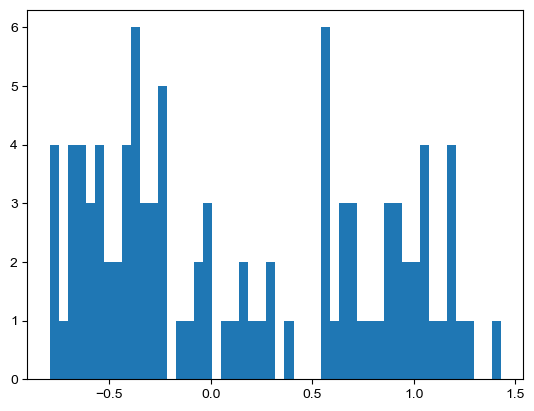

2D result shape:
['0.88 (15)', '1.05 (11)', '1.15 (12)', '1.04 (11)', '1.18 (10)', '1.09 (10)', '1.18 ( 7)', '1.07 ( 7)', '1.17 ( 5)', '1.18 ( 6)', 'nan ( 2)']
['0.94 (14)', '1.00 (12)', '1.05 (12)', '0.94 (12)', '0.91 (10)', '0.88 ( 8)', '0.95 ( 9)', '0.69 ( 8)', '1.25 ( 5)', 'nan ( 4)', 'nan ( 1)']
['0.74 (15)', '0.81 (11)', '0.77 (13)', '0.92 (13)', '0.87 (12)', '0.99 (11)', '0.70 (11)', '1.43 ( 9)', '1.27 ( 6)', '0.41 ( 6)', 'nan ( 0)']
['0.55 (15)', '0.58 (11)', '0.58 (13)', '0.62 (13)', '0.65 (12)', '0.65 (10)', '0.54 (11)', '0.70 (10)', '0.63 ( 5)', '0.21 ( 6)', 'nan ( 0)']
['0.31 (15)', '0.54 (11)', '0.55 (14)', '0.25 (13)', '0.29 (12)', '0.07 (10)', '0.12 (11)', '0.17 (11)', '-0.08 ( 6)', '-0.25 ( 7)', 'nan ( 1)']
['0.01 (15)', '0.00 (11)', '0.18 (13)', '0.00 (13)', '-0.07 (12)', '-0.14 ( 9)', '-0.10 (11)', '-0.39 (10)', '-0.38 ( 7)', '-0.22 ( 7)', 'nan ( 1)']
['-0.23 (17)', '-0.26 (13)', '-0.24 (14)', '-0.26 (14)', '-0.32 (12)', '-0.28 ( 9)', '-0.33 (11)', '-0.53 (12)', '-0.2

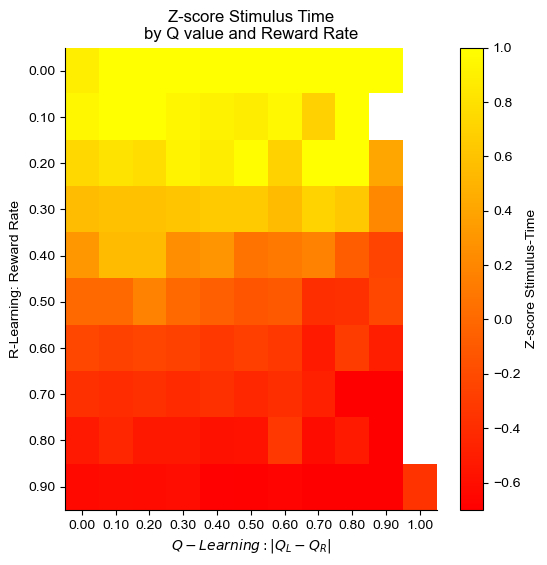

In [378]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore

def plotQ_R_Heatmap(df):
    df = df.copy()
    # BIN_SIZE = 0.05
    BIN_SIZE = 0.1
    NUM_BINS = int(1/BIN_SIZE) + 1
    BINS = np.arange(0, 1 + BIN_SIZE, BIN_SIZE, dtype=np.float64)
    print("Number of bins:", NUM_BINS, " - Bins:", BINS)
    twod_res = np.zeros((NUM_BINS, NUM_BINS))
    twod_num_subjects = np.zeros((NUM_BINS, NUM_BINS))
    print("2d array shape:", twod_res.shape)
    # df["Q_val"].abs().hist(bins=np.arange(0, 1.01, .1), density=True)
    # plt.show()
    # df["RewardRate"].hist(bins=np.arange(0, 1.01, .1), density=True)
    # plt.show()
    df["Q_val_abs"] = df["Q_val"].abs()
    df["Q_val_digi"] = np.digitize(df["Q_val_abs"], bins=BINS, right=True)
    df["RewardRate_digi"] = np.digitize(df["RewardRate"], bins=BINS, right=True)
    # display(df[["Q_val_abs", "Q_val_digi", "RewardRate", "RewardRate_digi"]])

    # df = df[df.calcStimulusTime.notnull()] 
    for subj, subj_df in df.groupby("Name"):
        # print("Processing subject:", subj)
        zscore_time = zscore(subj_df["SimRT"].values)
        # zscore_time = zscore(subj_df["calcStimulusTime"].values)
        subj_df = subj_df.copy()
        subj_df["zscore_time"] = zscore_time
        # for bin_rng1, rr_df in subj_df.groupby(pd.cut(subj_df["RewardRate"], bins=BINS)):
        #     bin_idx1 = int(bin_rng1.left / BIN_SIZE)
        #     for bin_rng2, q_df in rr_df.groupby(pd.cut(rr_df["Q_val"].abs(), bins=BINS)):
        #         bin_idx2 = int(bin_rng2.left / BIN_SIZE)
        #         if len(q_df) > 0:
        #             mean_zscore_time = q_df["zscore_time"].mean()
        #             if subj == "vgat-96":
        #                 print(f"Subject: {subj}, RR bin: {bin_idx1}, Q bin: {bin_idx2}, Mean zscore time: {mean_zscore_time}")
        #             twod_res[bin_idx1, bin_idx2] += mean_zscore_time
        #             twod_num_subjects[bin_idx1, bin_idx2] += 1
        #
        for (rr_val, qq_val), r_q_df in subj_df.groupby(["RewardRate_digi", "Q_val_digi"]):
            # print(f"Subject: {subj}, RR bin: {rr_val}, Q bin: {qq_val}, Count: {len(r_q_df)}")
            rr_bin_idx = rr_val - 1
            q_bin_idx = qq_val - 1
            twod_res[rr_bin_idx, q_bin_idx] += r_q_df["zscore_time"].median()#mean()
            twod_num_subjects[rr_bin_idx, q_bin_idx] += 1
        #
        # for idx, row in subj_df.iterrows():
        #     rr_bin_idx = row["RewardRate_digi"] - 1
        #     q_bin_idx = row["Q_val_digi"] - 1
        #     twod_res[rr_bin_idx, q_bin_idx] += row["zscore_time"]
        #     twod_num_subjects[rr_bin_idx, q_bin_idx] += 1
            
        # break
    # Normalize by number of subjects
    twod_res = np.divide(twod_res, twod_num_subjects, where=twod_num_subjects != 0)
    twod_res[twod_num_subjects <= 4] = np.nan  # Set empty bins to NaN for better visualization
    plt.hist(twod_res.flatten(), bins=50)
    plt.show()
    print("2D result shape:")
    for (row_val, row_count) in zip(twod_res, twod_num_subjects):
        print([f"{val:3.2f} ({int(count):-2})" 
               for (val, count) in zip(row_val, row_count)])

    fig, ax = plt.subplots(figsize=(6, 6))
    cax = ax.imshow(twod_res, cmap="autumn",
                    # origin='lower',
                    aspect='auto', 
                    vmin=-.7, vmax=1.,
                    # vmin=-.8, vmax=1.3,
                    )
    cbar = fig.colorbar(cax, ax=ax, orientation='vertical')
    cbar.set_label("Z-score Stimulus-Time")
    # Set ticks and labels
    ax.set_xticks(BINS/BIN_SIZE)
    ax.set_yticks(BINS/BIN_SIZE)
    ax.set_xticklabels([f"{_bin:.2f}" for _bin in BINS])
    ax.set_yticklabels([f"{_bin:.2f}" for _bin in BINS])
    # Set equal aspect ratio
    # ax.set_aspect('equal')
    ax.set_xlabel("$Q-Learning: |Q_L - Q_R|$")
    ax.set_ylabel("R-Learning: Reward Rate")
    ax.set_title("Z-score Stimulus Time\nby Q value and Reward Rate")
    # Move x-axis to the top
    # ax.xaxis.set_ticks_position('top')
    # ax.xaxis.set_label_position('top')
    # ax.spines[['bottom', 'right']].set_visible(False)
    ax.spines[['top', 'right']].set_visible(False)
    print("Get xlim:", ax.get_xlim())
    # ax.set_xlim(-0.5, 7.5)
    # ax.set_xlim(-0.5, 5.5)
    print("Get ylim:", ax.get_ylim())
    ax.set_ylim(9.5, -0.5)
    plt.show()


plotQ_R_Heatmap(df_model_behavior)

Number of bins: 101 
	- Bins: [0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99 1.  ] 
	- Long Bins: [-1.0000000e+00 -9.9000000e-01 -9.8000000e-01 -9.7000000e-01
 -9.6000000e-01 -9.5000000e-01 -9.4000000e-01 -9.3000000e-01
 -9.2000000e-01 -9.1000000e-01 -9.0000000e-01 -8.9000000e-01
 -8.8000000e-01 -8.7000000e-01 -8.6000000e-01 -8.5000000e-01
 -8.4000000e-01 -8.3000000e-01 -8.2000000e-01 -8.1000000e-01
 -8.0000000e-01 -7.9000000e-01 -7.8000000e-01 -7.7000000e-01
 -7.6000000e-01 -7.5000000e-01 -7.4000000e-01 -7.3000000e-01
 -7.2000000e-0

,Q_relative,Q_val,DV
30,-0.073771,-0.073771,1.000000
31,-0.036687,-0.036687,1.000000
32,0.019026,-0.019026,-1.000000
33,-0.019027,-0.019027,1.000000
34,0.010061,-0.010061,-1.000000
...,...,...,...
11010989,0.603766,-0.603766,-0.446008
11010990,0.612520,-0.612520,-0.715916
11010991,-0.614828,-0.614828,0.169483
11010995,-0.032312,0.032312,-0.261378


c:\Users\float\miniconda3\Lib\site-packages\IPython\lib\pretty.py:778: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  output = repr(obj)
c:\Users\float\miniconda3\Lib\site-packages\IPython\core\formatters.py:344: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  return method()


,DVabs,DV,DVstr,valid,calcStimulusTime,ChoiceCorrect,ChoiceLeft,Name,Date,SessionNum,...,SimRT,SimStartingPoint,SimChoiceCorrect,SimChoiceLeft,Q_L,Q_R,Q_val,RewardRate,LeftRewarded,Q_relative
30,1.0,1.000000,Easy,True,1.2517,1.0,1.0,Avgat1,2021-06-15,3,...,0.505,-0.004154,1.0,1.0,0.711960,0.999996,-0.073771,0.999890,NaN,-0.073771
31,1.0,1.000000,Easy,True,1.2897,1.0,1.0,Avgat1,2021-06-15,3,...,0.715,-0.002066,1.0,1.0,0.844549,0.999996,-0.036687,0.999975,NaN,-0.036687
32,1.0,-1.000000,Easy,True,0.9000,1.0,0.0,Avgat1,2021-06-15,3,...,0.625,-0.001071,1.0,0.0,0.916105,0.999996,-0.019026,0.999994,NaN,0.019026
33,1.0,1.000000,Easy,True,1.1409,1.0,1.0,Avgat1,2021-06-15,3,...,0.970,-0.001071,1.0,1.0,0.916105,0.999998,-0.019027,0.999999,NaN,-0.019027
34,1.0,-1.000000,Easy,True,0.7141,0.0,1.0,Avgat1,2021-06-15,3,...,0.650,-0.000567,1.0,0.0,0.954723,0.999998,-0.010061,1.000000,NaN,0.010061
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11010989,0.6,-0.446008,Med,True,0.9817,1.0,1.0,widefield_1,2021-06-15,Random_39995,...,0.925,-0.563931,1.0,0.0,0.058701,0.946624,-0.603766,0.000005,False,0.603766
11010990,1.0,-0.715916,Easy,True,0.7425,1.0,0.0,widefield_1,2021-06-15,Random_39995,...,0.465,-0.572107,1.0,0.0,0.058701,0.985566,-0.612520,0.997725,False,0.612520
11010991,1.0,0.169483,Easy,True,0.5879,1.0,1.0,widefield_1,2021-06-15,Random_39995,...,0.510,-0.574263,0.0,0.0,0.058701,0.996097,-0.614828,0.999995,True,-0.614828
11010995,0.6,-0.261378,Med,True,1.2792,1.0,0.0,widefield_1,2021-06-15,Random_39995,...,0.970,0.030180,1.0,0.0,0.931164,0.802420,0.032312,1.000000,False,-0.032312


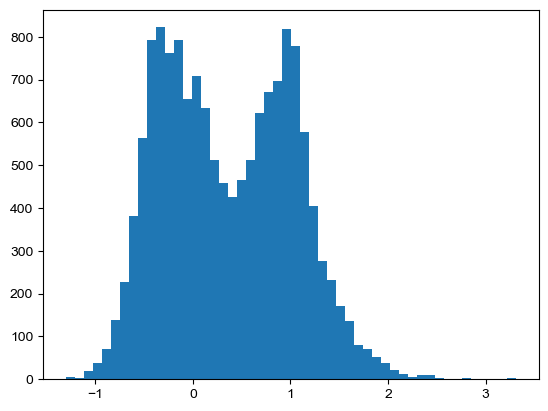

2D result shape:
['1.46 (145)', 'nan ( 3)', '1.26 (267)', '1.37 (58)', '1.37 (207)', '1.34 (795)', 'nan ( 0)', '1.41 (197)', '2.09 (13)', '1.95 (40)', '1.72 (72)', '1.87 (19)', 'nan ( 0)', '1.76 (71)', '1.88 (246)', '1.89 (81)', '1.30 (18)', 'nan ( 1)', '1.74 (22)', '1.78 (55)', 'nan ( 2)', 'nan ( 3)', '1.04 ( 8)', 'nan ( 1)', '1.97 ( 5)', '1.14 (14)', 'nan ( 0)', 'nan ( 0)', '1.30 (32)', '1.63 (16)', '1.22 (28)', '0.94 (13)', '1.16 ( 5)', '1.56 (10)', 'nan ( 2)', 'nan ( 1)', '1.62 (110)', '1.34 (66)', '1.60 (918)', '1.68 (375)', 'nan ( 3)', '1.69 (317)', '1.58 (1018)', '1.61 (2059)', '1.60 (772)', '1.08 (12)', '1.61 (298)', '1.51 (595)', '1.50 (459)', '1.48 (130)', '1.13 (2408)', '1.21 (26)', '1.12 (7555)', '1.08 (163)', '1.14 (2239)', '1.13 (276)', '1.12 (22)', '1.53 (31)', '1.11 (26)', '0.93 (36)', '1.00 (28)', '1.13 (18)', '1.42 ( 7)', 'nan ( 1)', '1.41 (52)', '1.40 (840)', '1.42 (4835)', '1.40 (2325)', '1.38 (1212)', '1.19 (176)', '1.36 (4812)', '1.32 (14237)', '1.34 (4304)', '1.3

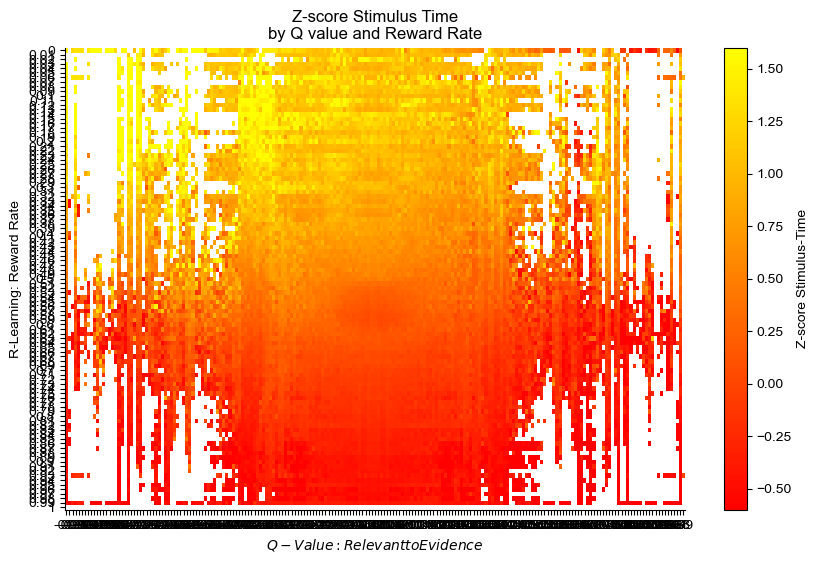

In [379]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore

def plotQ_R_Heatmap(df):
    df = df.copy()
    BIN_SIZE = 0.01
    # BIN_SIZE = 0.1
    NUM_BINS = int(1/BIN_SIZE) + 1
    BINS = np.arange(0, 1 + BIN_SIZE, BIN_SIZE, dtype=np.float64)
    LONG_BINS = np.arange(-1, 1 + BIN_SIZE, BIN_SIZE, dtype=np.float64)
    print("Number of bins:", NUM_BINS, 
          "\n\t- Bins:", BINS,
          "\n\t- Long Bins:", LONG_BINS)
    twod_res = np.zeros((BINS.shape[0], LONG_BINS.shape[0]))
    twod_num_subjects = np.zeros((BINS.shape[0], LONG_BINS.shape[0]))
    print("2d array shape:", twod_res.shape)
    # df["Q_val"].abs().hist(bins=np.arange(0, 1.01, .1), density=True)
    # plt.show()
    # df["RewardRate"].hist(bins=np.arange(0, 1.01, .1), density=True)
    # plt.show()
    df["Q_relative"] = df["Q_val"].abs() * (np.sign(df["DV"]) * np.sign(df["Q_val"]))
    dv_0_idx = df["DV"] == 0
    df.loc[dv_0_idx, "Q_relative"] = df.loc[dv_0_idx, "Q_val"]
    display(df[["Q_relative", "Q_val", "DV"]])
    display(df)
    
    
    df["Q_relative_digi"] = np.digitize(df["Q_relative"], bins=LONG_BINS, right=True)
    df["RewardRate_digi"] = np.digitize(df["RewardRate"], bins=BINS, right=True)
    # display(df[["Q_val_abs", "Q_val_digi", "RewardRate", "RewardRate_digi"]])

    # df = df[df.calcStimulusTime.notnull()] 
    for subj, subj_df in df.groupby("Name"):
        # print("Processing subject:", subj)
        zscore_time = zscore(subj_df["SimRT"].values)
        # zscore_time = zscore(subj_df["calcStimulusTime"].values)
        subj_df = subj_df.copy()
        subj_df["zscore_time"] = zscore_time
        # for bin_rng1, rr_df in subj_df.groupby(pd.cut(subj_df["RewardRate"], bins=BINS)):
        #     bin_idx1 = int(bin_rng1.left / BIN_SIZE)
        #     for bin_rng2, q_df in rr_df.groupby(pd.cut(rr_df["Q_val"].abs(), bins=BINS)):
        #         bin_idx2 = int(bin_rng2.left / BIN_SIZE)
        #         if len(q_df) > 0:
        #             mean_zscore_time = q_df["zscore_time"].mean()
        #             if subj == "vgat-96":
        #                 print(f"Subject: {subj}, RR bin: {bin_idx1}, Q bin: {bin_idx2}, Mean zscore time: {mean_zscore_time}")
        #             twod_res[bin_idx1, bin_idx2] += mean_zscore_time
        #             twod_num_subjects[bin_idx1, bin_idx2] += 1
        #
        # for (rr_val, qq_val), r_q_df in subj_df.groupby(["RewardRate_digi", "Q_relative_digi"]):
        #     # print(f"Subject: {subj}, RR bin: {rr_val}, Q bin: {qq_val}, Count: {len(r_q_df)}")
        #     rr_bin_idx = rr_val - 1
        #     q_bin_idx = qq_val - 1
        #     twod_res[rr_bin_idx, q_bin_idx] += r_q_df["zscore_time"].median()#mean()
        #     twod_num_subjects[rr_bin_idx, q_bin_idx] += 1
        #
        for idx, row in subj_df.iterrows():
            rr_bin_idx = row["RewardRate_digi"] - 1
            q_bin_idx = row["Q_relative_digi"] - 1
            twod_res[rr_bin_idx, q_bin_idx] += row["zscore_time"]
            twod_num_subjects[rr_bin_idx, q_bin_idx] += 1
            
        # break
    # Normalize by number of subjects
    twod_res = np.divide(twod_res, twod_num_subjects, where=twod_num_subjects != 0)
    twod_res[twod_num_subjects <= 4] = np.nan  # Set empty bins to NaN for better visualization
    plt.hist(twod_res.flatten(), bins=50)
    plt.show()
    print("2D result shape:")
    for (row_val, row_count) in zip(twod_res, twod_num_subjects):
        print([f"{val:3.2f} ({int(count):-2})" 
               for (val, count) in zip(row_val, row_count)])

    fig, ax = plt.subplots(figsize=(10, 6))
    cax = ax.imshow(twod_res, cmap="autumn",
                    # origin='lower',
                    aspect='auto', 
                    vmin=-.6, vmax=1.6,
                    # vmin=-.8, vmax=1.3,
                    )
    cbar = fig.colorbar(cax, ax=ax, orientation='vertical')
    cbar.set_label("Z-score Stimulus-Time")
    # Set ticks and labels
    print("Ticks:", LONG_BINS/BIN_SIZE)
    ax.set_xticks(LONG_BINS/BIN_SIZE - min(LONG_BINS/BIN_SIZE))
    ax.set_xticklabels([f"{np.round(_bin, 3):.2g}" for _bin in LONG_BINS])
    ax.set_yticks(BINS/BIN_SIZE)
    ax.set_yticklabels([f"{_bin:.2g}" for _bin in BINS])
    # Set equal aspect ratio
    # ax.set_aspect('equal')
    ax.set_xlabel("$Q-Value: Relevant to Evidence$")
    ax.set_ylabel("R-Learning: Reward Rate")
    ax.set_title("Z-score Stimulus Time\nby Q value and Reward Rate")
    # Move x-axis to the top
    # ax.xaxis.set_ticks_position('top')
    # ax.xaxis.set_label_position('top')
    # ax.spines[['bottom', 'right']].set_visible(False)
    ax.spines[['top', 'right']].set_visible(False)
    print("Get xlim:", ax.get_xlim())
    # ax.set_xlim(-0.5, 7.5)
    # ax.set_xlim(-0.5, 5.5)
    print("Get ylim:", ax.get_ylim())
    # ax.set_ylim(9.5, -0.5)
    plt.show()


plotQ_R_Heatmap(df_model_behavior)

## As Surface Plot

In [421]:
%matplotlib widget

Number of bins: 11 
	- Bins: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ] 
	- Long Bins: [-1.00000000e+00 -9.00000000e-01 -8.00000000e-01 -7.00000000e-01
 -6.00000000e-01 -5.00000000e-01 -4.00000000e-01 -3.00000000e-01
 -2.00000000e-01 -1.00000000e-01 -2.22044605e-16  1.00000000e-01
  2.00000000e-01  3.00000000e-01  4.00000000e-01  5.00000000e-01
  6.00000000e-01  7.00000000e-01  8.00000000e-01  9.00000000e-01
  1.00000000e+00]
Number of DV bins: 4  - Bins: [0.         0.33333333 0.66666667 1.        ]
2d array shape: (11, 21, 4)


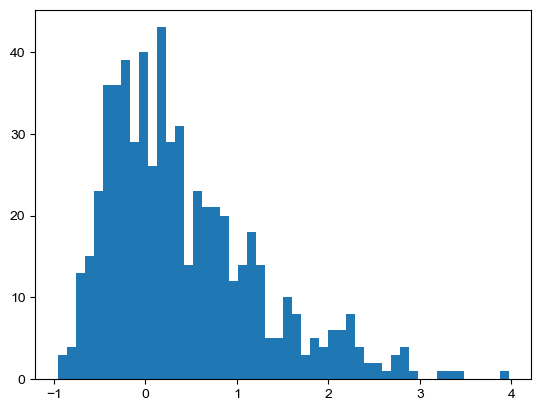

twod_num_observ: (11, 21, 4)  - Max: 266794.0


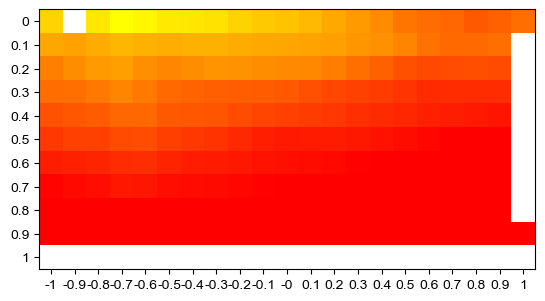

Easy data shape: (11, 21)  - Med data shape: (11, 21)  - Hard data shape: (11, 21)
Ticks: [-1.00000000e+01 -9.00000000e+00 -8.00000000e+00 -7.00000000e+00
 -6.00000000e+00 -5.00000000e+00 -4.00000000e+00 -3.00000000e+00
 -2.00000000e+00 -1.00000000e+00 -2.22044605e-15  1.00000000e+00
  2.00000000e+00  3.00000000e+00  4.00000000e+00  5.00000000e+00
  6.00000000e+00  7.00000000e+00  8.00000000e+00  9.00000000e+00
  1.00000000e+01]
Current xlim: (-1.1, 1.0999999999999996)
Current ylim: (-0.05, 1.05)
Current zlim: (-0.8073611425374605, 3.5031242894973107)
Current viewing angle: -60 30


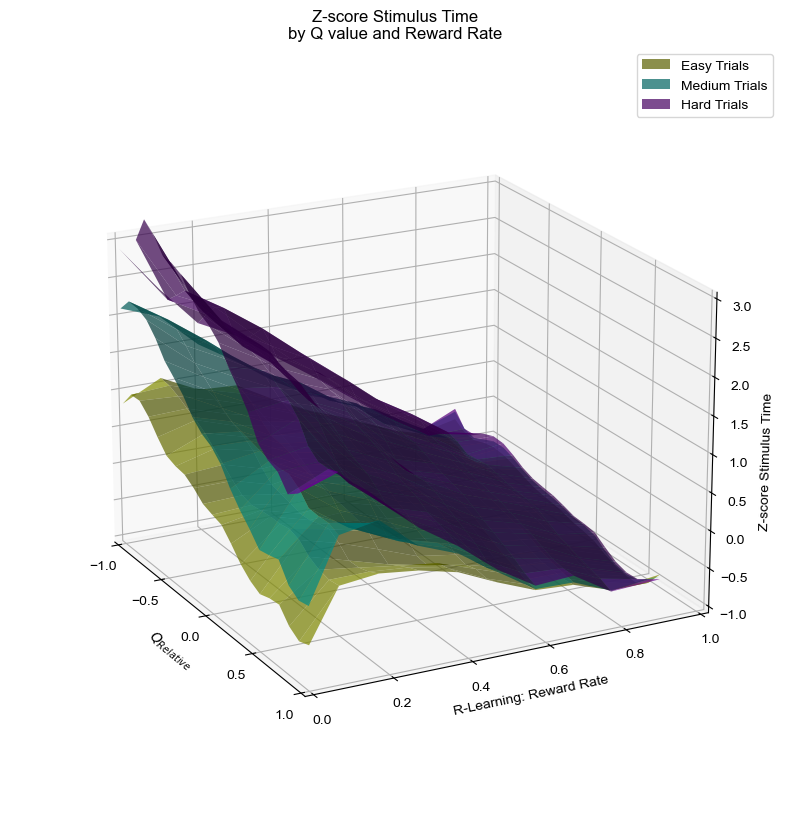

In [70]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore
# from scipy.ndimage import gaussian_filter
from ...paper_fast_slow.code.pipeline.utils import filterNanGaussianConserving


def plotQ_R_Heatmap(df, save_figs=False):
    df = df.copy()
    df = df[df["SimChoiceCorrect"] == True]
    # df = df.sample(frac=.1, replace=False, random_state=42)
    # BIN_SIZE = 0.05
    BIN_SIZE = 0.1
    NUM_BINS = int(1/BIN_SIZE) + 1
    BINS = np.arange(0, 1 + BIN_SIZE, BIN_SIZE, dtype=np.float64)
    LONG_BINS = np.arange(-1, 1 + BIN_SIZE, BIN_SIZE, dtype=np.float64)
    print("Number of bins:", NUM_BINS, 
          "\n\t- Bins:", BINS,
          "\n\t- Long Bins:", LONG_BINS)
    DV_BIN_SIZE = 1/3 #0.01
    DV_BINS = np.arange(0, 1 + DV_BIN_SIZE, DV_BIN_SIZE)
    print("Number of DV bins:", DV_BINS.shape[0], " - Bins:", DV_BINS)
    twod_res = np.zeros((BINS.shape[0], LONG_BINS.shape[0], DV_BINS.shape[0]))
    twod_num_observ = np.zeros((BINS.shape[0], LONG_BINS.shape[0], DV_BINS.shape[0]))
    print("2d array shape:", twod_res.shape)
    # df["Q_val"].abs().hist(bins=np.arange(0, 1.01, .1), density=True)
    # plt.show()
    # df["RewardRate"].hist(bins=np.arange(0, 1.01, .1), density=True)
    # plt.show()
    df["Q_relative"] = df["Q_val"].abs() * (np.sign(df["DV"]) * np.sign(df["Q_val"]))
    dv_0_idx = df["DV"] == 0
    df.loc[dv_0_idx, "Q_relative"] = df.loc[dv_0_idx, "Q_val"]
    
    df["RewardRate_digi"] = np.digitize(df["RewardRate"], bins=BINS, right=True)
    df["Q_relative_digi"] = np.digitize(df["Q_relative"], bins=LONG_BINS, right=True)
    df["DV_digi"] = np.digitize(df["DV"].abs(), bins=DV_BINS, right=True)
    # display(df[["Q_relative", "Q_relative_digi", "RewardRate", "RewardRate_digi",
    #             "DV", "DV_digi"]])

    # df = df[df.calcStimulusTime.notnull()] 
    res_df = df.copy()
    res_df["zscore_time"] = np.nan
    for subj, subj_df in df.groupby("Name"):
        zscore_time = zscore(subj_df["SimRT"].values)
        res_df.loc[subj_df.index, "zscore_time"] = zscore_time
   
    def countEntries(grp_df):
        rr_bin_idx = grp_df["RewardRate_digi"].values - 1
        q_bin_idx = grp_df["Q_relative_digi"].values - 1
        dv_idx = grp_df["DV_digi"].values - 1
        twod_res[rr_bin_idx, q_bin_idx, dv_idx] = grp_df["zscore_time"].sum()
        twod_num_observ[rr_bin_idx, q_bin_idx, dv_idx] = len(grp_df)
    res_df.groupby(["RewardRate_digi", "Q_relative_digi", "DV_digi"]).apply(countEntries)
            
    # Normalize by number of subjects
    twod_res = np.divide(twod_res, twod_num_observ, where=twod_num_observ != 0)
    MIN_NUM_OBSERV = 1
    twod_res[twod_num_observ <= MIN_NUM_OBSERV] = np.nan  # Set empty bins to NaN for better visualization
    #
    fig_hist, ax_hist = plt.subplots()
    ax_hist.hist(twod_res.flatten(), bins=50)
    plt.show()
    fig_hist, ax_imshow = plt.subplots()
    print("twod_num_observ:", twod_num_observ.shape, " - Max:", twod_num_observ.max())
    twod_num_observ[twod_num_observ <= MIN_NUM_OBSERV] = np.nan  # Set empty bins to NaN for better visualization
    # display(twod_num_observ[:, :, 0])
    # for i in range(twod_num_observ.shape[0]):
    #     print(f"Row {i} - ", end=" ")
    #     for j in range(twod_num_observ.shape[1]):
    #         print(f"{twod_num_observ[i, j, 0]:5,.5g} ", end=" ")
    #     print()
    #

    twod_res = filterNanGaussianConserving(twod_res, sigma=1.0, axis=1)

    # twod_num_observ = np.log(twod_num_observ + 1)  # Log scale for better visualization
    # norm_observ = twod_num_observ[:, :, 0].astype(float)/np.nanmax(twod_num_observ)
    # ax_imshow.imshow(norm_observ, cmap="autumn",
    #                  vmin=0, vmax=1)
    norm_observ = twod_res[:, :, 0].astype(float)/np.nanmax(twod_res[:, :, 0])
    ax_imshow.imshow(norm_observ, cmap="autumn", vmin=0, vmax=1)
    ax_imshow.set_xticks(LONG_BINS/BIN_SIZE - min(LONG_BINS/BIN_SIZE))
    ax_imshow.set_xticklabels([f"{np.round(_bin, 3):.2g}" for _bin in LONG_BINS])
    ax_imshow.set_yticks(BINS/BIN_SIZE)
    ax_imshow.set_yticklabels([f"{_bin:.2g}" for _bin in BINS])
    plt.show()
    

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={"projection": "3d"})
    # twod_res = twod_res.transpose((1, 2, 0))  # Transpose to have Q on x-axis and RewardRate on y-axis
    easy_data = twod_res[:, :, 2]
    med_data = twod_res[:, :, 1]
    hard_data = twod_res[:, :, 0]
    print("Easy data shape:", easy_data.shape, " - Med data shape:", med_data.shape,
            " - Hard data shape:", hard_data.shape)
               
    from ...common.util.clr import Difficulty as DifficultyColor
    for (color, data, name) in [(DifficultyColor.Easy, easy_data, "Easy"),
                                (DifficultyColor.Med,  med_data, "Medium"),
                                (DifficultyColor.Hard, hard_data, "Hard")
                                ]:
        # MAke a plot surface where height is zscore time
        X, Y = np.meshgrid(LONG_BINS, BINS)
        surf = ax.plot_surface(X, Y, data, 
                               color=color, alpha=0.7, rstride=1, cstride=1,
                               linewidth=0, antialiased=True,
                               label=f"{name} Trials")
    ax.legend()
    # Set ticks and labels
    print("Ticks:", LONG_BINS/BIN_SIZE)
    ax.set_xticks(np.arange(-1, 1.25, 0.5))
    ax.set_xlabel("$Q_{Relative}$")
    ax.set_ylabel("R-Learning: Reward Rate")
    ax.set_zlabel("Z-score Stimulus Time")
    ax.set_title("Z-score Stimulus Time\nby Q value and Reward Rate")
    # Print current viewing angle
    # PRint axes limits
    print("Current xlim:", ax.get_xlim())
    print("Current ylim:", ax.get_ylim())
    print("Current zlim:", ax.get_zlim())
    ax.set_xlim(-1, 1)
    ax.set_ylim(0, 1)
    ax.set_zlim(-1, 3)
    print("Current viewing angle:", ax.azim, ax.elev)
    # Set viewer angle
    ax.view_init(azim=-27.5, elev=20,)
    ax.set_box_aspect(aspect=None, zoom=.9)
    # Set tight layout
    if save_figs:
        fig.savefig(f"{fig_save_prefix}/Q_R_Heatmap.svg", dpi=300, bbox_inches='tight')
    plt.show()


plotQ_R_Heatmap(df_model_behavior, save_figs=False)

## As Cube

Number of bins: 11 
	- Bins: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ] 
	- Long Bins: [-1.00000000e+00 -9.00000000e-01 -8.00000000e-01 -7.00000000e-01
 -6.00000000e-01 -5.00000000e-01 -4.00000000e-01 -3.00000000e-01
 -2.00000000e-01 -1.00000000e-01 -2.22044605e-16  1.00000000e-01
  2.00000000e-01  3.00000000e-01  4.00000000e-01  5.00000000e-01
  6.00000000e-01  7.00000000e-01  8.00000000e-01  9.00000000e-01
  1.00000000e+00]
Number of DV bins: 4  - Bins: [0.         0.33333333 0.66666667 1.        ]
2d array shape: (11, 21, 4)


,Q_relative,Q_relative_digi,RewardRate,RewardRate_digi,DV,DV_digi
30,-0.073771,10,0.999890,10,1.000000,3
31,-0.036687,10,0.999975,10,1.000000,3
32,0.019026,11,0.999994,10,-1.000000,3
33,-0.019027,10,0.999999,10,1.000000,3
34,0.010061,11,1.000000,10,-1.000000,3
...,...,...,...,...,...,...
11010986,0.283955,13,0.002275,1,-0.740490,3
11010989,0.603766,17,0.000005,1,-0.446008,2
11010990,0.612520,17,0.997725,10,-0.715916,3
11010995,-0.032312,10,1.000000,10,-0.261378,1


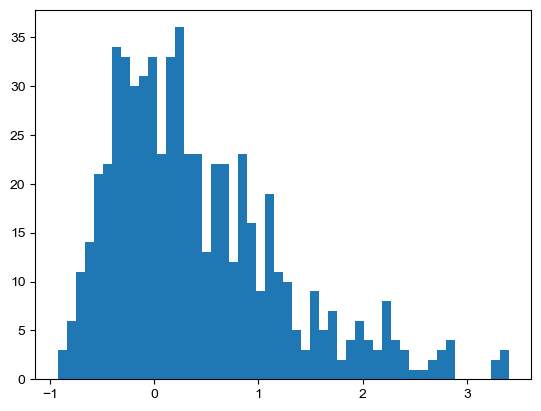

2D result shape:
Easy data shape: (11, 21)  - Med data shape: (11, 21)  - Hard data shape: (11, 21)
Ticks: [-1.00000000e+01 -9.00000000e+00 -8.00000000e+00 -7.00000000e+00
 -6.00000000e+00 -5.00000000e+00 -4.00000000e+00 -3.00000000e+00
 -2.00000000e+00 -1.00000000e+00 -2.22044605e-15  1.00000000e+00
  2.00000000e+00  3.00000000e+00  4.00000000e+00  5.00000000e+00
  6.00000000e+00  7.00000000e+00  8.00000000e+00  9.00000000e+00
  1.00000000e+01]
Get xlim: (-1.05, 22.05)
Get ylim: (-0.55, 11.55)


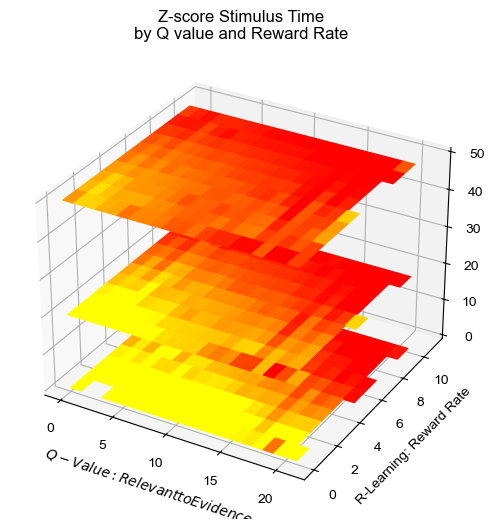

In [413]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore

def plotQ_R_Heatmap(df):
    df = df.copy()
    df = df[df["SimChoiceCorrect"] == True]
    # df = df.sample(frac=.1, replace=False, random_state=42)
    # BIN_SIZE = 0.05
    BIN_SIZE = 0.1
    NUM_BINS = int(1/BIN_SIZE) + 1
    BINS = np.arange(0, 1 + BIN_SIZE, BIN_SIZE, dtype=np.float64)
    LONG_BINS = np.arange(-1, 1 + BIN_SIZE, BIN_SIZE, dtype=np.float64)
    print("Number of bins:", NUM_BINS, 
          "\n\t- Bins:", BINS,
          "\n\t- Long Bins:", LONG_BINS)
    DV_BIN_SIZE = 1/3 #0.01
    DV_BINS = np.arange(0, 1 + DV_BIN_SIZE, DV_BIN_SIZE)
    print("Number of DV bins:", DV_BINS.shape[0], " - Bins:", DV_BINS)
    twod_res = np.zeros((BINS.shape[0], LONG_BINS.shape[0], DV_BINS.shape[0]))
    twod_num_subjects = np.zeros((BINS.shape[0], LONG_BINS.shape[0], DV_BINS.shape[0]))
    print("2d array shape:", twod_res.shape)
    # df["Q_val"].abs().hist(bins=np.arange(0, 1.01, .1), density=True)
    # plt.show()
    # df["RewardRate"].hist(bins=np.arange(0, 1.01, .1), density=True)
    # plt.show()
    df["Q_relative"] = df["Q_val"].abs() * (np.sign(df["DV"]) * np.sign(df["Q_val"]))
    dv_0_idx = df["DV"] == 0
    df.loc[dv_0_idx, "Q_relative"] = df.loc[dv_0_idx, "Q_val"]
    
    df["RewardRate_digi"] = np.digitize(df["RewardRate"], bins=BINS, right=True)
    df["Q_relative_digi"] = np.digitize(df["Q_relative"], bins=LONG_BINS, right=True)
    df["DV_digi"] = np.digitize(df["DV"].abs(), bins=DV_BINS, right=True)
    display(df[["Q_relative", "Q_relative_digi", "RewardRate", "RewardRate_digi",
                "DV", "DV_digi"]])

    # df = df[df.calcStimulusTime.notnull()] 
    for subj, subj_df in df.groupby("Name"):
        # print("Processing subject:", subj)
        zscore_time = zscore(subj_df["SimRT"].values)
        # zscore_time = zscore(subj_df["calcStimulusTime"].values)
        subj_df = subj_df.copy()
        subj_df["zscore_time"] = zscore_time
        # for bin_rng1, rr_df in subj_df.groupby(pd.cut(subj_df["RewardRate"], bins=BINS)):
        #     bin_idx1 = int(bin_rng1.left / BIN_SIZE)
        #     for bin_rng2, q_df in rr_df.groupby(pd.cut(rr_df["Q_val"].abs(), bins=BINS)):
        #         bin_idx2 = int(bin_rng2.left / BIN_SIZE)
        #         if len(q_df) > 0:
        #             mean_zscore_time = q_df["zscore_time"].mean()
        #             if subj == "vgat-96":
        #                 print(f"Subject: {subj}, RR bin: {bin_idx1}, Q bin: {bin_idx2}, Mean zscore time: {mean_zscore_time}")
        #             twod_res[bin_idx1, bin_idx2] += mean_zscore_time
        #             twod_num_subjects[bin_idx1, bin_idx2] += 1
        #
        # for (rr_val, qq_val), r_q_df in subj_df.groupby(["RewardRate_digi", "Q_relative_digi"]):
        #     # print(f"Subject: {subj}, RR bin: {rr_val}, Q bin: {qq_val}, Count: {len(r_q_df)}")
        #     rr_bin_idx = rr_val - 1
        #     q_bin_idx = qq_val - 1
        #     twod_res[rr_bin_idx, q_bin_idx] += r_q_df["zscore_time"].median()#mean()
        #     twod_num_subjects[rr_bin_idx, q_bin_idx] += 1
        #
        for idx, row in subj_df.iterrows():
            rr_bin_idx = row["RewardRate_digi"] - 1
            q_bin_idx = row["Q_relative_digi"] - 1
            dv_idx = row["DV_digi"] - 1
            twod_res[rr_bin_idx, q_bin_idx, dv_idx] += row["zscore_time"]
            twod_num_subjects[rr_bin_idx, q_bin_idx, dv_idx] += 1
            
        # break
    # Normalize by number of subjects
    twod_res = np.divide(twod_res, twod_num_subjects, where=twod_num_subjects != 0)
    twod_res[twod_num_subjects <= 0] = np.nan  # Set empty bins to NaN for better visualization
    plt.hist(twod_res.flatten(), bins=50)
    plt.show()
    print("2D result shape:")
    # for (row_val, row_count) in zip(twod_res, twod_num_subjects):
    #     # print([f"{val:3.2f} ({int(count):-2})" 
    #     #        for (val, count) in zip(row_val, row_count)])
    #     for (val, count) in zip(row_val, row_count):
    #         print([f"{v:3.2f} ({int(c):-2})" for (v, c) in zip(val, count)])

    fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": "3d"})
    # twod_res = twod_res.transpose((1, 2, 0))  # Transpose to have Q on x-axis and RewardRate on y-axis
    # ax.set_box_aspect([1, .5, 1])  # Set aspect ratio to be equal
    # cmap="autumn",
    # ax.scatter(BINS[:-1], LONG_BINS[:-1], DV_BINS[:-1],
    easy_data = twod_res[:, :, 2]
    med_data = twod_res[:, :, 1]
    hard_data = twod_res[:, :, 0]
    print("Easy data shape:", easy_data.shape, " - Med data shape:", med_data.shape,
            " - Hard data shape:", hard_data.shape)
               
    from matplotlib.colors import Normalize
    norm = Normalize(vmin=-.5, vmax=1.5)
    ny, nx = easy_data.shape
    yi, xi = np.mgrid[0:ny + 1, 0:nx + 1]

    Z_POS = 50, 20, 0
    for (z_pos, data) in zip(Z_POS, [easy_data, med_data, hard_data]):
        zi = np.full_like(xi, z_pos)
        colors = plt.cm.autumn(norm(data))
        ax.plot_surface(xi, yi, zi, rstride=1, cstride=1, facecolors=colors, shade=False)

    

    # Set ticks and labels
    print("Ticks:", LONG_BINS/BIN_SIZE)
    # ax.set_xticks(LONG_BINS/BIN_SIZE - min(LONG_BINS/BIN_SIZE))
    # ax.set_xticklabels([f"{np.round(_bin, 3):.2g}" for _bin in LONG_BINS])
    # ax.set_yticks(BINS/BIN_SIZE)
    # ax.set_yticklabels([f"{_bin:.2g}" for _bin in BINS])
    # Set equal aspect ratio
    # ax.set_aspect('equal')
    ax.set_xlabel("$Q-Value: Relevant to Evidence$")
    ax.set_ylabel("R-Learning: Reward Rate")
    ax.set_title("Z-score Stimulus Time\nby Q value and Reward Rate")
    # Move x-axis to the top
    # ax.xaxis.set_ticks_position('top')
    # ax.xaxis.set_label_position('top')
    # ax.spines[['bottom', 'right']].set_visible(False)
    # ax.spines[['top', 'right']].set_visible(False)
    print("Get xlim:", ax.get_xlim())
    # ax.set_xlim(-0.5, 7.5)
    # ax.set_xlim(-0.5, 5.5)
    print("Get ylim:", ax.get_ylim())
    # ax.set_ylim(9.5, -0.5)
    plt.show()


plotQ_R_Heatmap(df_model_behavior)